In [ ]:
# COMP541 organized folder path helper
from pathlib import Path
import os

def _comp541_phase_dir():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == 'code':
        return cwd.parent
    if (cwd / 'Input').exists() and (cwd / 'Output').exists():
        return cwd
    if (cwd.parent / 'Input').exists() and (cwd.parent / 'Output').exists():
        return cwd.parent
    # Fallback for the intended layout: notebook/script is inside a Code folder.
    return cwd.parent if cwd.name.lower() == 'code' else cwd

PHASE_DIR = _comp541_phase_dir()
INPUT_DIR = PHASE_DIR / 'Input'
OUTPUT_DIR = PHASE_DIR / 'Output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('INPUT_DIR :', INPUT_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


1. Data Description

In [ ]:
import re
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Load your uploaded CSV file
file_path = INPUT_DIR / "Tripadvisor cleaned.csv"
df = pd.read_csv(file_path, encoding='latin1')

df.head()
df.info()
df.shape

C:\Users\hasik\AppData\Local\Temp\ipykernel_24120\4277597124.py:9: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878949 entries, 0 to 878948
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   hotel_class    843646 non-null  float64
 1   region_id      878949 non-null  int64  
 2   State          878949 non-null  object 
 3   Address        878949 non-null  object 
 4   Zipcode        878940 non-null  object 
 5   City           877085 non-null  object 
 6   type           878949 non-null  object 
 7   hotel_id       878949 non-null  int64  
 8   name           878949 non-null  object 
 9   title          878561 non-null  object 
 10  text           878561 non-null  object 
 11  id             878561 non-null  float64
 12  Service        878561 non-null  object 
 13  Cleanliness    770621 non-null  object 
 14  Overall        768740 non-null  float64
 15  Value          765897 non-null  float64
 16  Location       756129 non-null  float64
 17  Sleep_quality  656541 non-nul

(878949, 19)

In [ ]:
df = df.astype({'Overall': object, 'Value': object,'Location': object,'Sleep_quality': object,'Room': object})

In [ ]:
df.isna().sum()

hotel_class       35303
region_id             0
State                 0
Address               0
Zipcode               9
City               1864
type                  0
hotel_id              0
name                  0
title               388
text                388
id                  388
Service             388
Cleanliness      108328
Overall          110209
Value            113052
Location         122820
Sleep_quality    222408
Room             346886
dtype: int64

In [ ]:
df.head()

,hotel_class,region_id,State,Address,Zipcode,City,type,hotel_id,name,title,text,id,Service,Cleanliness,Overall,Value,Location,Sleep_quality,Room
0,3.0,60763,'NY','2130 Broadway at 75th Street','10023','New York City'},hotel,93338,Hotel Beacon,"Truly is ""Jewel of the Upper Wets Side""",Stayed in a king suite for 11 nights and yes i...,147643103.0,5,5.0,5.0,5.0,5.0,5.0,5.0
1,3.0,60763,'NY','2130 Broadway at 75th Street','10023','New York City'},hotel,93338,Hotel Beacon,My home away from home!,"On every visit to NYC, the Hotel Beacon is the...",147639004.0,5,5.0,5.0,5.0,5.0,5.0,5.0
2,3.0,60763,'NY','2130 Broadway at 75th Street','10023','New York City'},hotel,93338,Hotel Beacon,Excellent location,Loved the hotel. Great location - only 2 block...,147634248.0,5,5.0,5.0,5.0,5.0,5.0,5.0
3,3.0,60763,'NY','2130 Broadway at 75th Street','10023','New York City'},hotel,93338,Hotel Beacon,All-round fantastic NYC hotel,Our first stay on the upper west side and can'...,147625002.0,5,5.0,5.0,4.0,5.0,5.0,5.0
4,3.0,60763,'NY','2130 Broadway at 75th Street','10023','New York City'},hotel,93338,Hotel Beacon,Great hotel in nice area,"Great room, very big with huge bed! Great loca...",147623184.0,5,5.0,5.0,4.0,5.0,5.0,5.0


Categorical Data Description

In [ ]:
import pandas as pd

# 1. Select only categorical and object columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# 2. Generate the high-level descriptive summary table
df[categorical_cols].describe()


,State,Address,Zipcode,City,type,name,title,text,Service,Cleanliness,Overall,Value,Location,Sleep_quality,Room
count,878949,878949,878940,877085,878949,878949,878561,878561,878561,770621.0,768740.0,765897.0,756129.0,656541.0,532063.0
unique,17,4322,925,26,1,4254,625914,876811,13,12.0,5.0,5.0,5.0,5.0,5.0
top,'NY','401 Seventh Avenue at 33rd Street','10036','New York City'},hotel,Hotel Pennsylvania New York,Great location,#NAME?,5,5.0,5.0,5.0,5.0,5.0,5.0
freq,267086,5456,54052,262126,878949,5456,3332,80,373526,382571.0,312813.0,302685.0,406718.0,327352.0,219029.0


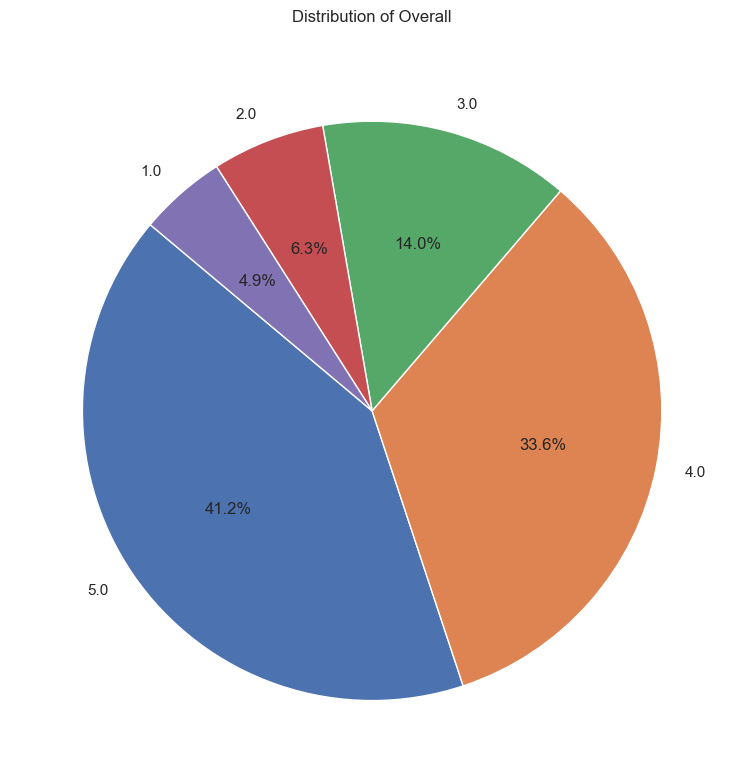

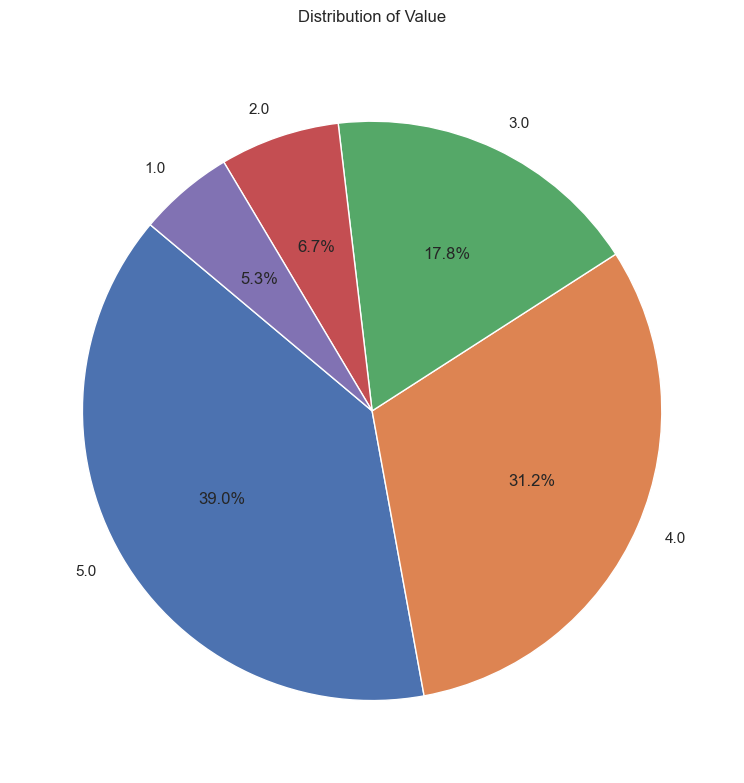

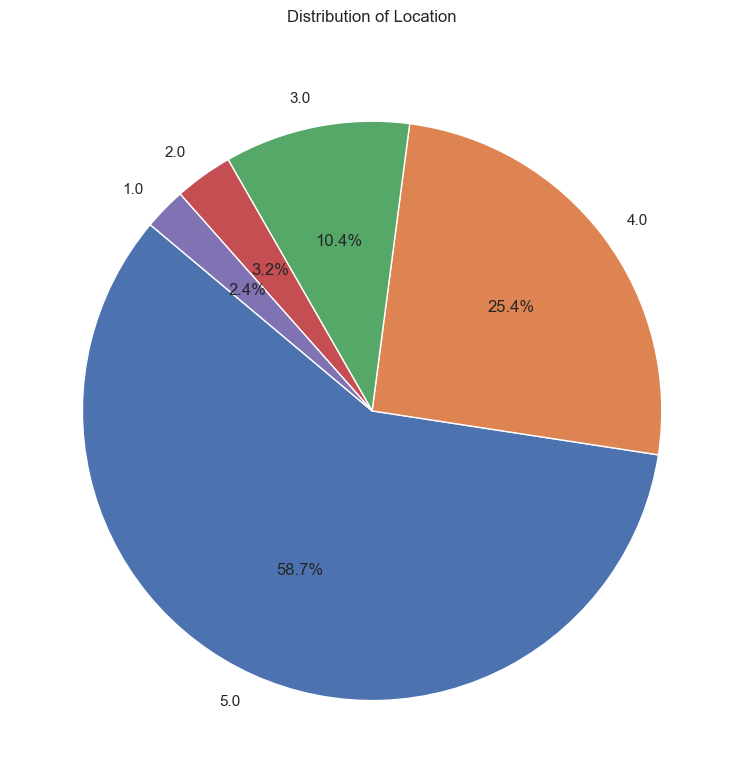

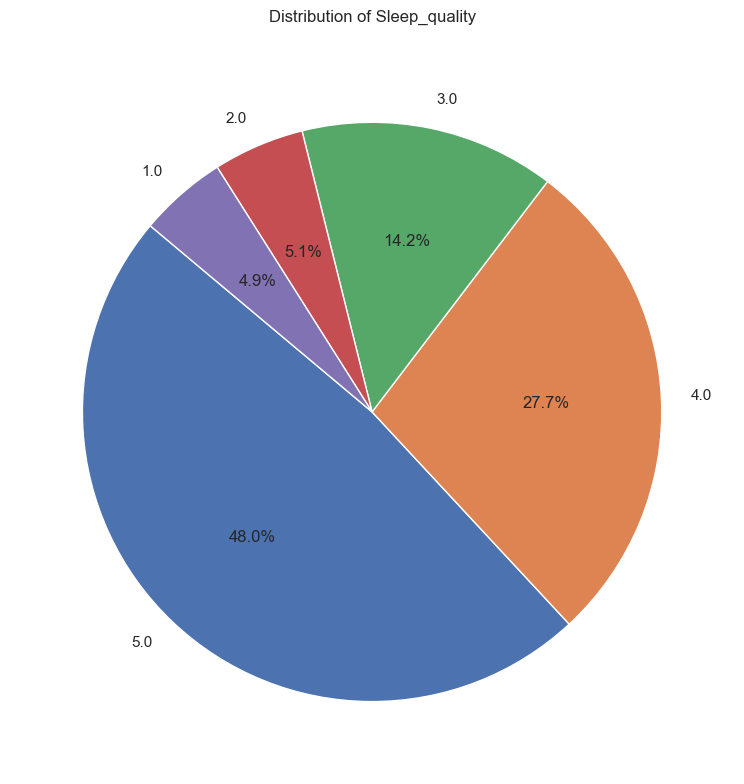

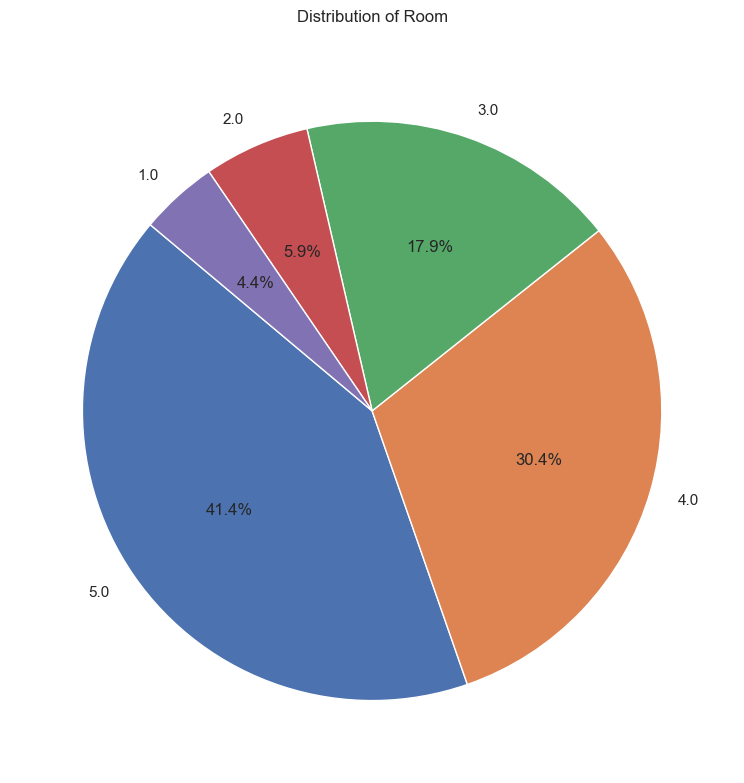

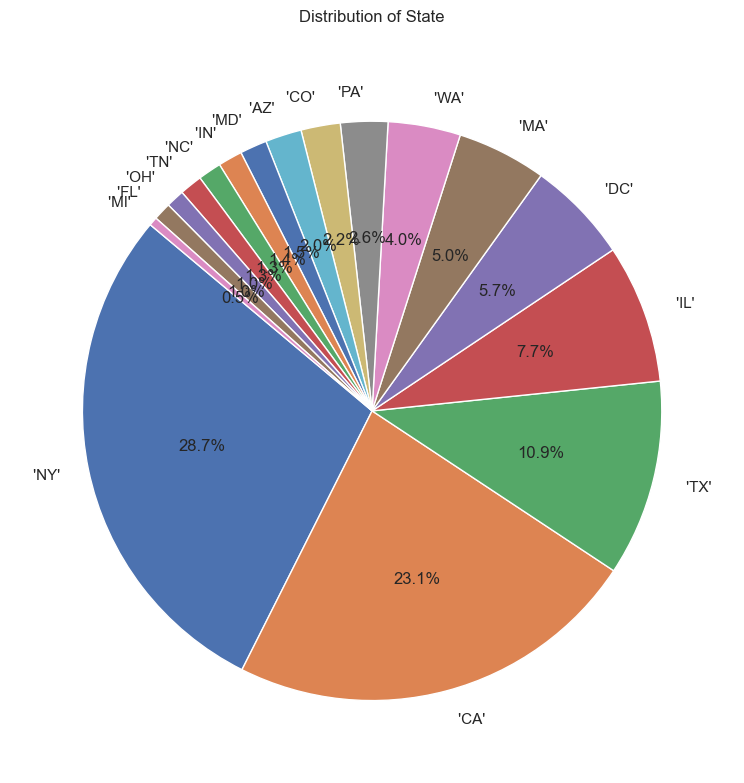

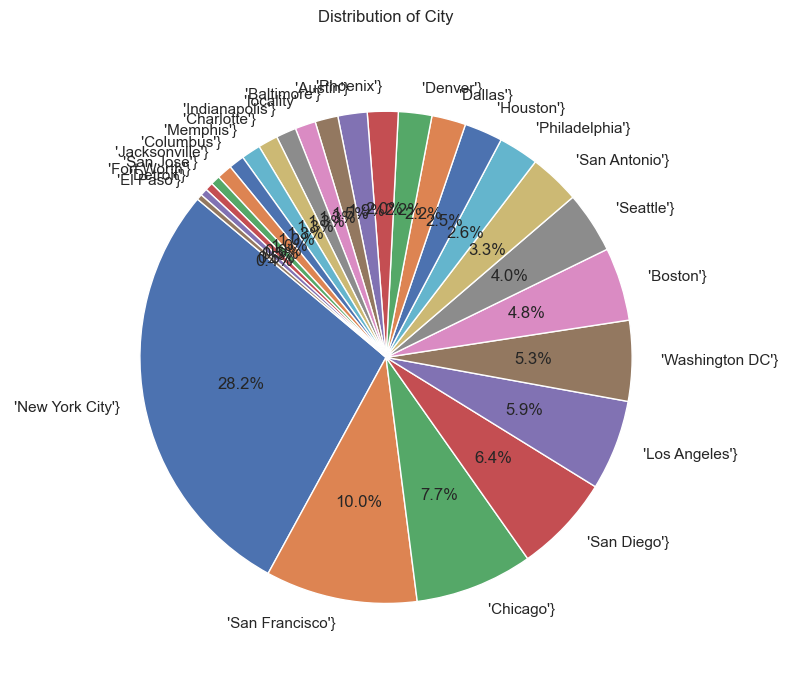

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select categorical and object columns
# (Removed duplicate 'State' to prevent errors)
categorical_cols = ['Overall', 'Value', 'Location', 'Sleep_quality', 'Room', 'State', 'City']

# 2. Visualize the frequency of each category using pie charts
for col in categorical_cols:
    # Get value counts for the column
    counts = df[col].value_counts()

    plt.figure(figsize=(8, 8))

    # Create the pie chart
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white'})

    plt.title(f'Distribution of {col}', pad=20)
    plt.tight_layout()
    plt.show()


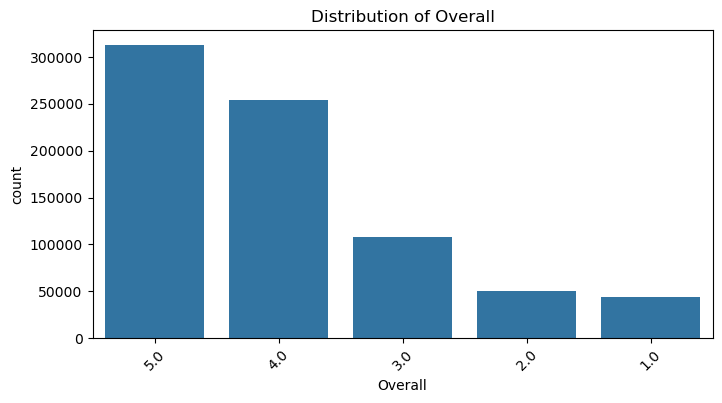

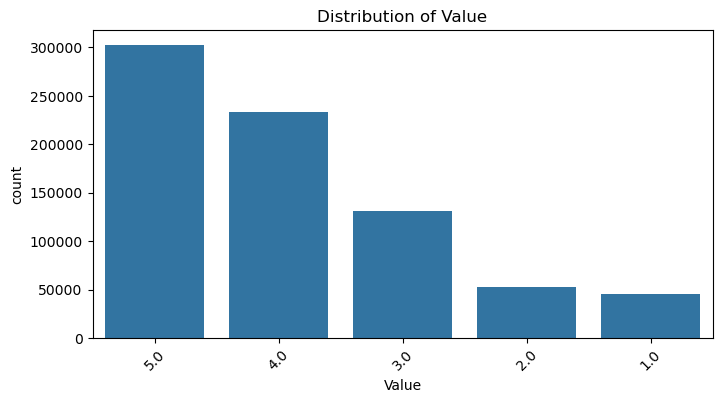

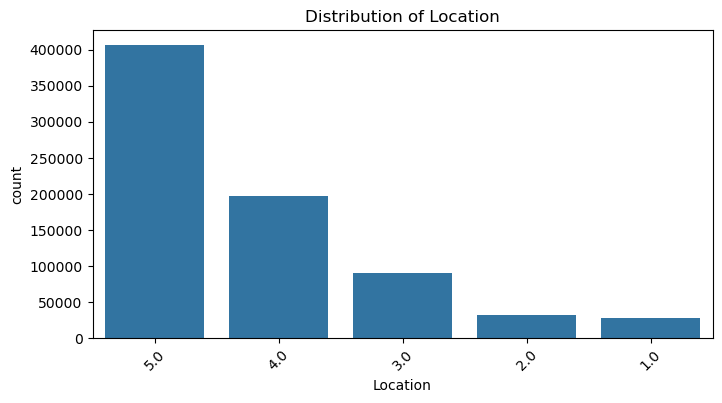

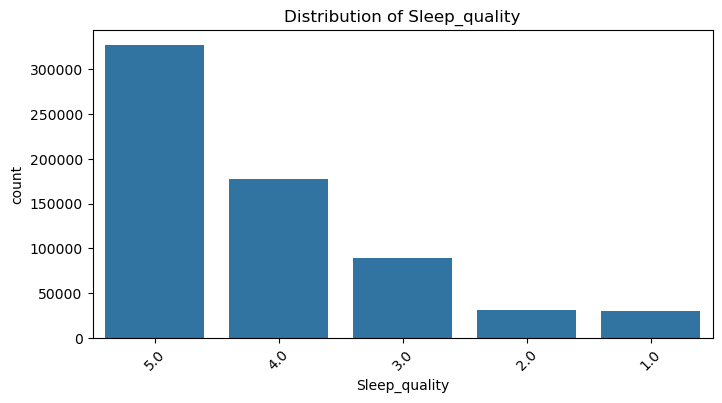

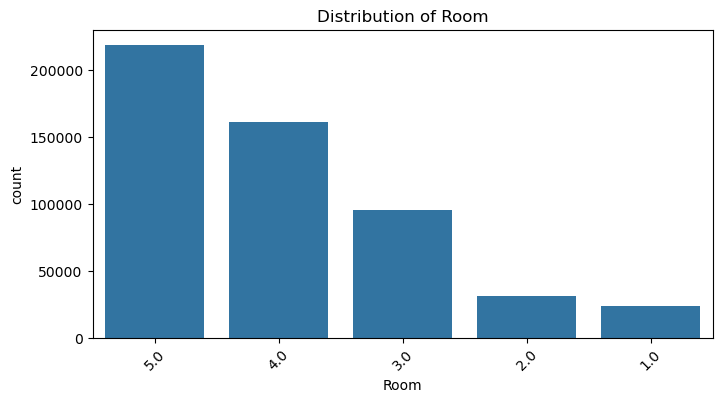

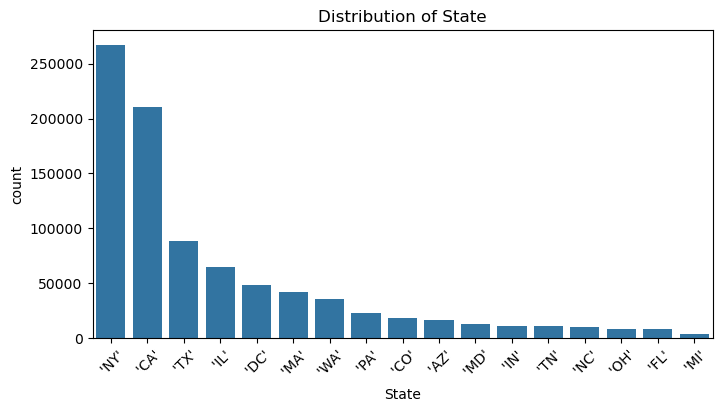

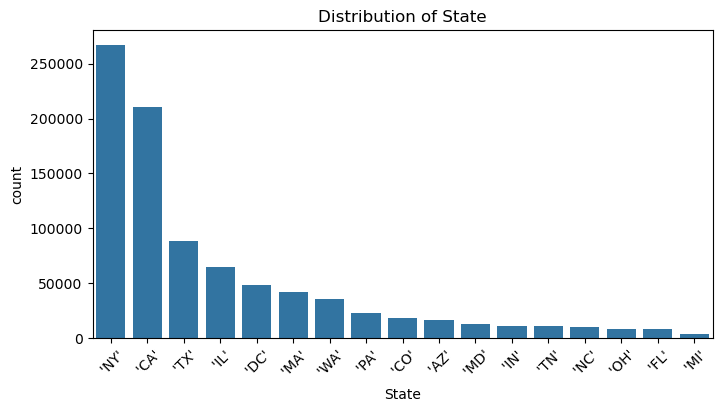

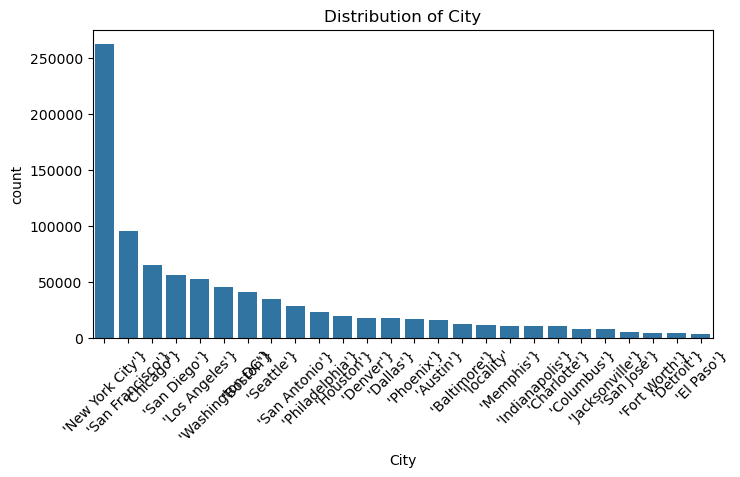

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select categorical and object columns
categorical_cols = ['Overall', 'Value', 'Location', 'Sleep_quality', 'Room', 'State', 'State', 'City']

# 2. Visualize the frequency of each category
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
# Loop through each column to print data distributions
categorical_cols = ['City', 'State']
for col in categorical_cols:
    print(f"\n=== Descriptive Statistics for Column: {col} ===")

    # Combine raw counts and percentages
    stats_df = pd.DataFrame({
        'Count': df[col].value_counts(dropna=False),
        'Percentage (%)': df[col].value_counts(normalize=True, dropna=False) * 100
    })

    print(stats_df)



=== Descriptive Statistics for Column: City ===
                    Count  Percentage (%)
City                                     
 'New York City'}  262126       29.822663
 'San Francisco'}   94919       10.799148
 'Chicago'}         64553        7.344340
 'San Diego'}       56224        6.396731
 'Los Angeles'}     52620        5.986695
 'Washington DC'}   45059        5.126464
 'Boston'}          40450        4.602087
 'Seattle'}         34948        3.976112
 'San Antonio'}     28422        3.233635
 'Philadelphia'}    22832        2.597648
 'Houston'}         19632        2.233577
 'Denver'}          17871        2.033224
 'Dallas'}          17540        1.995565
 'Phoenix'}         16290        1.853350
 'Austin'}          15484        1.761649
 'Baltimore'}       12500        1.422153
 'locality'         10894        1.239435
 'Memphis'}         10859        1.235453
 'Indianapolis'}    10770        1.225327
 'Charlotte'}       10568        1.202345
 'Columbus'}         8108  

Descriptive Statistics with Visualization


=== Descriptive Statistics for Column: City ===
                    Count  Percentage (%)
City                                     
 'New York City'}  262126       29.822663
 'San Francisco'}   94919       10.799148
 'Chicago'}         64553        7.344340
 'San Diego'}       56224        6.396731
 'Los Angeles'}     52620        5.986695
 'Washington DC'}   45059        5.126464
 'Boston'}          40450        4.602087
 'Seattle'}         34948        3.976112
 'San Antonio'}     28422        3.233635
 'Philadelphia'}    22832        2.597648
 'Houston'}         19632        2.233577
 'Denver'}          17871        2.033224
 'Dallas'}          17540        1.995565
 'Phoenix'}         16290        1.853350
 'Austin'}          15484        1.761649
 'Baltimore'}       12500        1.422153
 'locality'         10894        1.239435
 'Memphis'}         10859        1.235453
 'Indianapolis'}    10770        1.225327
 'Charlotte'}       10568        1.202345
 'Columbus'}         8108  

C:\Users\hasik\AppData\Local\Temp\ipykernel_24120\3657165678.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


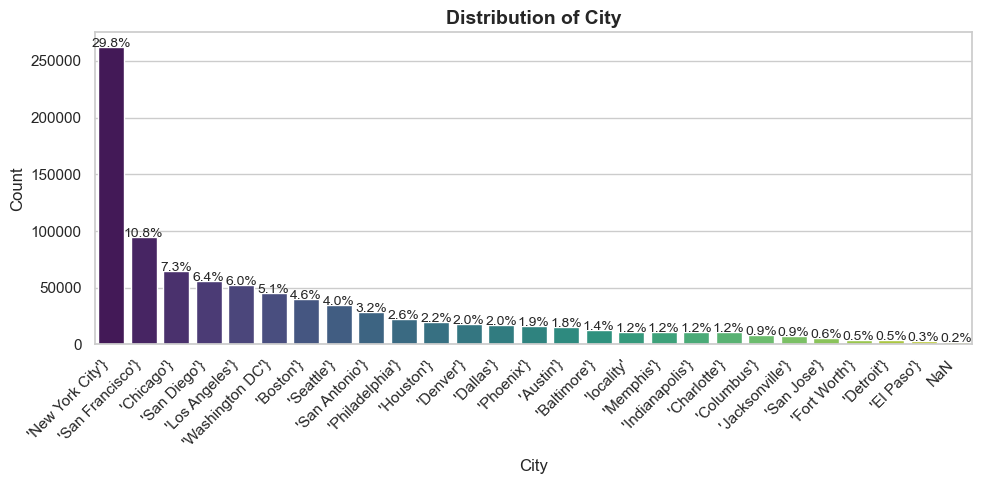


=== Descriptive Statistics for Column: State ===
        Count  Percentage (%)
State                        
'NY'   267086       30.386974
'CA'   210342       23.931081
'TX'    88704       10.092053
'IL'    64553        7.344340
'DC'    48344        5.500205
'MA'    41890        4.765919
'WA'    35519        4.041076
'PA'    22832        2.597648
'CO'    18158        2.065876
'AZ'    16298        1.854260
'MD'    12710        1.446045
'IN'    10983        1.249561
'TN'    10880        1.237842
'NC'    10577        1.203369
'OH'     8113        0.923034
'FL'     7956        0.905172
'MI'     4004        0.455544
--------------------------------------------------


C:\Users\hasik\AppData\Local\Temp\ipykernel_24120\3657165678.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


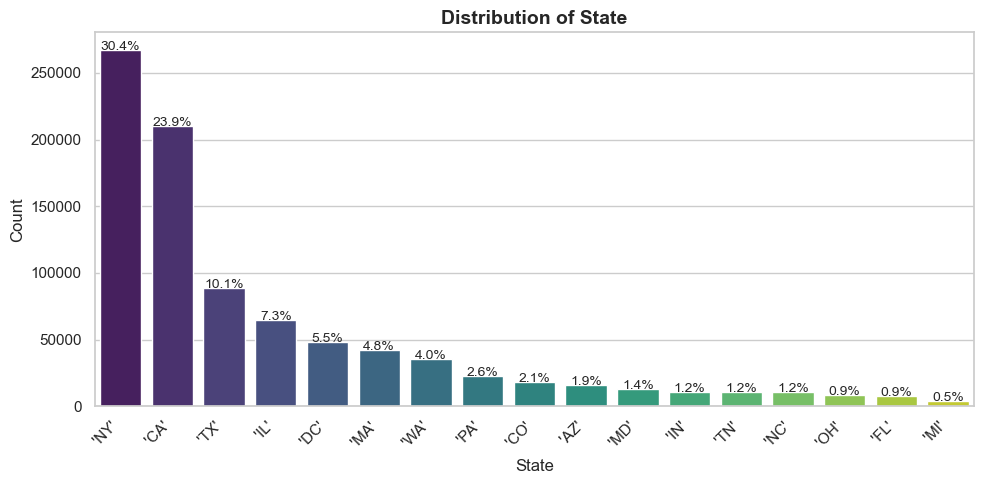

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

for col in categorical_cols:
    print(f"\n=== Descriptive Statistics for Column: {col} ===")

    # Combine raw counts and percentages
    stats_df = pd.DataFrame({
        'Count': df[col].value_counts(dropna=False),
        'Percentage (%)': df[col].value_counts(normalize=True, dropna=False) * 100
    })

    # Print the text summary
    print(stats_df)
    print("-" * 50)

    # VISUALIZATION
    plt.figure(figsize=(10, 5))

    # Create a countplot; converts NaN to a string so it displays nicely on the axis
    plot_data = df.copy()
    plot_data[col] = plot_data[col].fillna("NaN")

    ax = sns.countplot(
        data=plot_data,
        x=col,
        order=plot_data[col].value_counts().index,
        palette="viridis"
    )

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)

    # Add percentage labels above each bar
    total = len(plot_data)
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{(100 * height / total):.1f}%'
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 5,
            percentage,
            ha="center",
            fontsize=10
        )

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Text Description

In [ ]:
df = df.dropna()
df.isna().sum()

hotel_class      0
region_id        0
State            0
Address          0
Zipcode          0
City             0
type             0
hotel_id         0
name             0
title            0
text             0
id               0
Service          0
Cleanliness      0
Overall          0
Value            0
Location         0
Sleep_quality    0
Room             0
dtype: int64

In [ ]:
df['text_length'] = df['text'].apply(len)

# Calculate word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Describe the new numerical text stats
df[['text_length', 'word_count']].describe()

,text_length,word_count
count,510170.000000,510170.000000
mean,837.830817,153.189794
std,690.848710,129.143552
min,6.000000,1.000000
25%,399.000000,71.000000
50%,651.000000,118.000000
75%,1049.000000,193.000000
max,22387.000000,4235.000000


In [ ]:
skewness = df[['text_length', 'word_count']].skew()
print(skewness)

text_length    3.001186
word_count     2.980422
dtype: float64


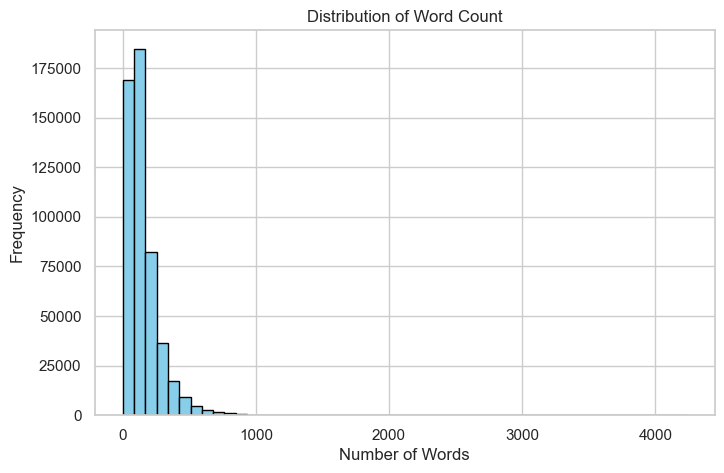

In [ ]:
import matplotlib.pyplot as plt

# Plotting the distribution of word counts
df['word_count'].plot.hist(bins=50, color='skyblue', edgecolor='black', figsize=(8, 5))
plt.title('Distribution of Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

2. Data Cleaning

In [ ]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 510170 entries, 0 to 878560
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   hotel_class    510170 non-null  float64
 1   region_id      510170 non-null  int64  
 2   State          510170 non-null  object 
 3   Address        510170 non-null  object 
 4   Zipcode        510170 non-null  object 
 5   City           510170 non-null  object 
 6   type           510170 non-null  object 
 7   hotel_id       510170 non-null  int64  
 8   name           510170 non-null  object 
 9   title          510170 non-null  object 
 10  text           510170 non-null  object 
 11  id             510170 non-null  float64
 12  Service        510170 non-null  object 
 13  Cleanliness    510170 non-null  object 
 14  Overall        510170 non-null  object 
 15  Value          510170 non-null  object 
 16  Location       510170 non-null  object 
 17  Sleep_quality  510170 non-null  ob

(510170, 21)

In [ ]:
# Returns a new DataFrame with clean rows
df = df.dropna()
df.isna().sum()

hotel_class      0
region_id        0
State            0
Address          0
Zipcode          0
City             0
type             0
hotel_id         0
name             0
title            0
text             0
id               0
Service          0
Cleanliness      0
Overall          0
Value            0
Location         0
Sleep_quality    0
Room             0
text_length      0
word_count       0
dtype: int64

In [ ]:
import re
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# CONFIGURATION
TEXT_COLS = ['Address', 'title', 'text']
CAT_COLS = ['State', 'City', 'Zipcode', 'region_id', 'id', 'hotel_id']
NUM_COLS = ['hotel_class', 'Service', 'Cleanliness', 'Overall', 'Value', 'Location', 'Sleep_quality', 'Room']

# NEW: Clean numerical columns before processing
def clean_numerical(val):
    if pd.isna(val):
        return 0.0
    # Convert to string, strip spaces, and remove characters like '}' or '{'
    val_str = re.sub(r'[^0-9.]', '', str(val))
    # Return float if valid, otherwise return 0.0
    try:
        return float(val_str) if val_str else 0.0
    except ValueError:
        return 0.0

# Apply the numerical cleaning to all numeric columns
for col in NUM_COLS:
    df[col] = df[col].apply(clean_numerical)

# 2. Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

clean_text_cols = []
for col in TEXT_COLS:
    clean_col_name = f'clean_{col}'
    df[clean_col_name] = df[col].apply(clean_text)
    clean_text_cols.append(clean_col_name)

# 3. Setup the preprocessor for multiple columns
transformer_list = []

for col in clean_text_cols:
    transformer_list.append((f'text_{col}', TfidfVectorizer(max_features=1000), col))

transformer_list.append(('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS))
transformer_list.append(('num', StandardScaler(), NUM_COLS))

preprocessor = ColumnTransformer(transformers=transformer_list)

# 4. Convert all columns into a single numerical machine learning matrix
final_features = preprocessor.fit_transform(df)

# 5. Verify the results
print(f"Successfully loaded: {file_path}")
print(f"Dataset shape: {df.shape}")
print(f"Processed ML matrix shape: {final_features.shape}")


Successfully loaded: Tripadvisor cleaned.csv
Dataset shape: (510170, 24)
Processed ML matrix shape: (510170, 517057)


Chi-Square Test

In [ ]:
import pandas as pd
import scipy.stats as stats

# 1. Convert the continuous 'Overall' score to categorical 'Rating' bins
# (e.g., ratings under 4.0 as 'Low', 4.0 and above as 'High')
bins = [0, 3.9, 5.0]
labels = ['Low', 'High']
df['Rating_Category'] = pd.cut(df['Overall'], bins=bins, labels=labels)

# 2. Create a contingency table
contingency_table = pd.crosstab(df['City'], df['Rating_Category'])

# 3. Run the Chi-Square Test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_val}")


Chi-square statistic: 2945.0389463282163
p-value: 0.0


Rating_Category         Low       High
City                                  
'Austin'}         29.367347  70.632653
'Baltimore'}      26.042885  73.957115
'Boston'}         22.552013  77.447987
'Charlotte'}      30.430189  69.569811
'Chicago'}        20.929820  79.070180
'Columbus'}       36.452729  63.547271
'Dallas'}         24.215875  75.784125
'Denver'}         23.587773  76.412227
'Detroit'}        23.257732  76.742268
'El Paso'}        32.671674  67.328326
'Fort Worth'}     26.404494  73.595506
'Houston'}        26.410236  73.589764
'Indianapolis'}   28.751110  71.248890
'Jacksonville'}   28.247585  71.752415
'Los Angeles'}    30.532915  69.467085
'Memphis'}        32.380216  67.619784
'New York City'}  24.204269  75.795731
'Philadelphia'}   29.708637  70.291363
'Phoenix'}        25.288471  74.711529
'San Antonio'}    26.932332  73.067668
'San Diego'}      26.710366  73.289634
'San Francisco'}  25.563939  74.436061
'San Jose'}       32.826362  67.173638
'Seattle'}        21.8946

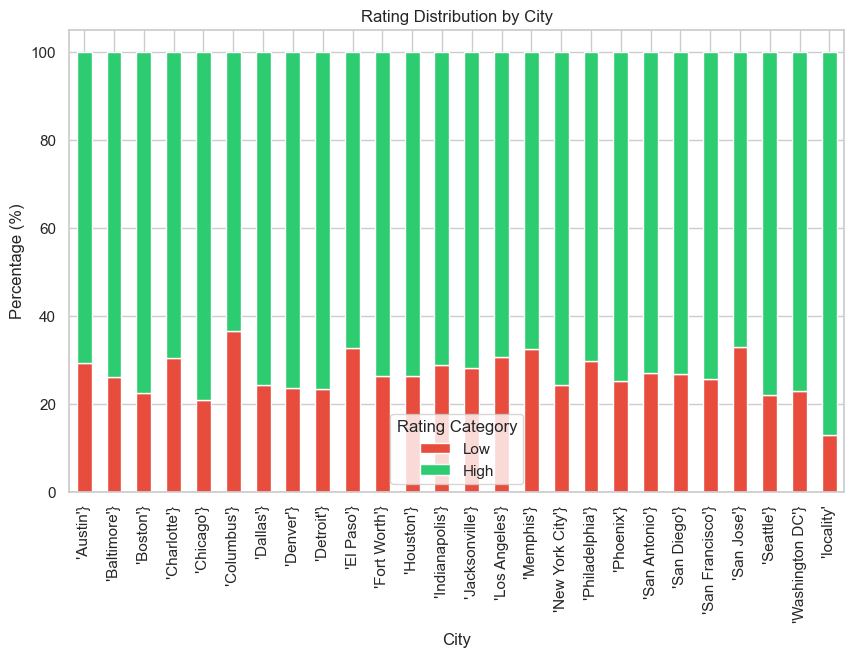

In [ ]:
# Calculate percentages by city
props = pd.crosstab(df['City'], df['Rating_Category'], normalize='index') * 100
print(props)
import matplotlib.pyplot as plt

props.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(10, 6))
plt.title('Rating Distribution by City')
plt.ylabel('Percentage (%)')
plt.xlabel('City')
plt.legend(title='Rating Category')
plt.show()